Dataset: 50 datapoints, 2 features



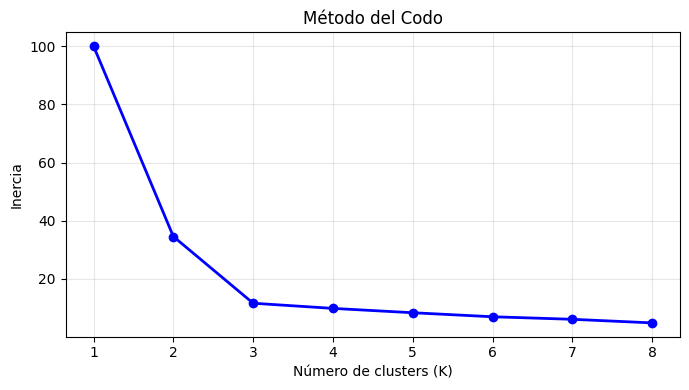

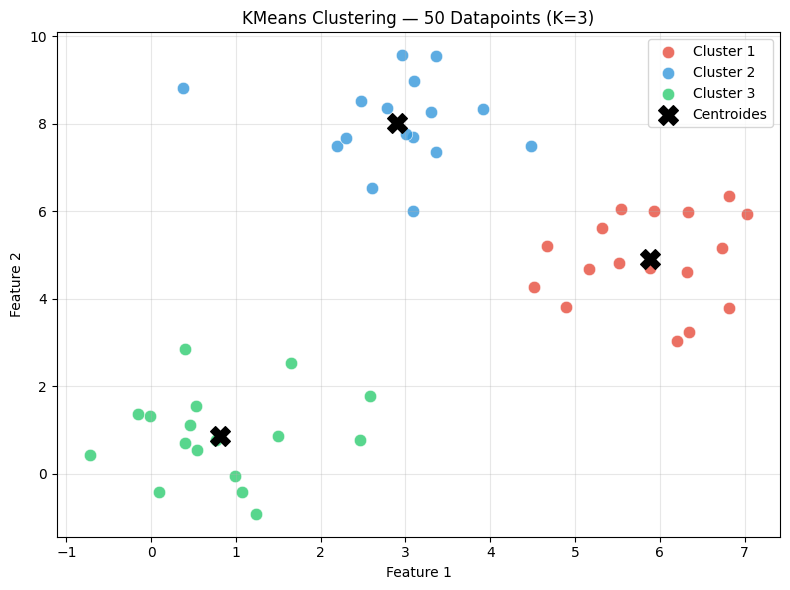

=== Resultados ===
Cluster 1: 17 puntos | Centroide → (5.89, 4.90)
Cluster 2: 16 puntos | Centroide → (2.90, 8.02)
Cluster 3: 17 puntos | Centroide → (0.81, 0.87)

Inercia final : 11.6635
Iteraciones   : 2


In [4]:
# ============================================================
# KMeans Clustering - 50 Datapoints
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ── 1. Generar 50 datapoints sintéticos (3 grupos) ──────────
np.random.seed(42)

grupo1 = np.random.randn(17, 2) + [1, 1]
grupo2 = np.random.randn(17, 2) + [6, 5]
grupo3 = np.random.randn(16, 2) + [3, 8]

X = np.vstack([grupo1, grupo2, grupo3])
print(f"Dataset: {X.shape[0]} datapoints, {X.shape[1]} features\n")

# ── 2. Escalar los datos ─────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 3. Método del codo para elegir K ────────────────────────
inercias = []
k_rango = range(1, 9)

for k in k_rango:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_rango, inercias, "bo-", linewidth=2)
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.xticks(k_rango)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 4. Entrenar KMeans con K=3 ───────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# ── 5. Visualizar clusters ───────────────────────────────────
colores = ["#e74c3c", "#3498db", "#2ecc71"]

plt.figure(figsize=(8, 6))
for i in range(3):
    mask = labels == i
    plt.scatter(X[mask, 0], X[mask, 1],
                c=colores[i], label=f"Cluster {i+1}",
                s=80, alpha=0.8, edgecolors="white", linewidths=0.5)

plt.scatter(centroids[:, 0], centroids[:, 1],
            c="black", marker="X", s=200, zorder=5, label="Centroides")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KMeans Clustering — 50 Datapoints (K=3)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 6. Resumen ───────────────────────────────────────────────
print("=== Resultados ===")
for i in range(3):
    n = np.sum(labels == i)
    cx, cy = centroids[i]
    print(f"Cluster {i+1}: {n:2d} puntos | Centroide → ({cx:.2f}, {cy:.2f})")

print(f"\nInercia final : {kmeans.inertia_:.4f}")
print(f"Iteraciones   : {kmeans.n_iter_}")


El script realiza un análisis de clustering utilizando el algoritmo K-Means en un conjunto de datos sintético. Se puede dividir en los siguientes pasos:

1.  **Generación de Datapoints Sintéticos:**
    *   Se utiliza `numpy` para crear 50 puntos de datos en un espacio bidimensional (2 features).
    *   Estos puntos se distribuyen artificialmente en 3 grupos distintos, cada uno con un promedio y una desviación estándar específicos, y con una ligera variación aleatoria.
    *   `np.random.seed(42)` asegura que los puntos generados sean los mismos cada vez que se ejecuta el script, lo que hace el experimento reproducible.
    *   `X = np.vstack([grupo1, grupo2, grupo3])` combina los tres grupos individuales en un único conjunto de datos `X`.

2.  **Escalado de los Datos:**
    *   Se emplea `StandardScaler` de la biblioteca `sklearn.preprocessing`.
    *   El escalado es un paso crucial en K-Means porque el algoritmo es sensible a la escala de las características. Si una característica tiene un rango de valores mucho mayor que otra, dominará la distancia euclidiana y, por lo tanto, la formación de los clústeres.
    *   `scaler.fit_transform(X)` calcula la media y la desviación estándar de cada característica en `X` y luego transforma los datos para que tengan una media de 0 y una desviación estándar de 1 (`X_scaled`).

3.  **Método del Codo para Elegir K (Número de Clústeres):**
    *   Esta sección busca determinar el número óptimo de clústeres (`K`) para el algoritmo K-Means.
    *   Se itera con `K` desde 1 hasta 8.
    *   Para cada `K`, se entrena un modelo `KMeans` (`km = KMeans(n_clusters=k, ...)`) con los datos escalados.
    *   Se registra la `inercia_` del modelo (`km.inertia_`), que es la suma de las distancias cuadradas de cada punto a su centroide asignado. Una menor inercia generalmente indica clústeres más compactos.
    *   Finalmente, se grafica la inercia en función de `K` (el "gráfico de codo"). El punto donde la disminución de la inercia se ralentiza significativamente (el "codo") sugiere el `K` más apropiado.

4.  **Entrenamiento de K-Means con K=3:**
    *   Basándose en el gráfico de codo (que en este caso, se espera que el "codo" sugiera `K=3` ya que generamos 3 grupos), se entrena el modelo `KMeans` definitivo con `n_clusters=3`.
    *   `kmeans.fit_predict(X_scaled)` entrena el modelo y asigna una etiqueta (`labels`) de clúster a cada punto de datos.
    *   `kmeans.cluster_centers_` obtiene las coordenadas de los centroides de los 3 clústeres en el espacio escalado. `scaler.inverse_transform` se usa para convertirlos de nuevo a la escala original de los datos para facilitar la interpretación.

5.  **Visualización de los Clústeres:**
    *   Se crea un gráfico de dispersión (`plt.scatter`) para visualizar los puntos de datos originales (`X`) coloreados según el clúster al que fueron asignados por K-Means.
    *   Los centroides calculados también se añaden al gráfico como marcadores grandes (`X`) para mostrar su ubicación.
    *   Esto permite una inspección visual de cómo el algoritmo ha agrupado los datos y dónde se encuentran los centros de esos grupos.

6.  **Resumen de Resultados:**
    *   Se imprime un resumen detallado de los resultados del clustering.
    *   Para cada clúster, se muestra el número de puntos asignados y las coordenadas de su centroide (en la escala original).
    *   Finalmente, se reporta la inercia final del modelo (`kmeans.inertia_`) y el número de iteraciones (`kmeans.n_iter_`) que el algoritmo necesitó para converger, lo que indica cuántas veces ajustó los centroides antes de que su posición se estabilizara.